# 데이터 확인하기 #
## 0. 라이브러리 임포트 & 경로 설정

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 0. 라이브러리 임포트 & 경로 설정

import os
import json
import pandas as pd
from PIL import Image
import unicodedata  # 0번 섹션에 추가 필요
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import matplotlib
import matplotlib.pyplot as plt
from collections import Counter
import subprocess
import matplotlib as mpl
import numpy as np
import matplotlib.patches as patches
!pip3 install ultralytics -q
from ultralytics import YOLO
from ultralytics.utils import LOGGER
import logging
import shutil
import unicodedata
!pip3 install iterative-stratification -q
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.6 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import unicodedata

# ── 디바이스 ──────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── 한글 폰트 ─────────────────────────────────────────────
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
subprocess.run(['fc-cache', '-fv'], capture_output=True)
mpl.font_manager.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
mpl.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# ── 경로 설정 ─────────────────────────────────────────────
BASE_DIR            = unicodedata.normalize('NFC', "/content/drive/MyDrive/data/초급_프로젝트/dataset/")

TRAIN_JSON_PATH     = os.path.join(BASE_DIR, "merged_annotations_train_final.json")
TEST_JSON_PATH      = os.path.join(BASE_DIR, "merged_annotations_test_final.json")
TRAIN_IMG_DIR       = os.path.join(BASE_DIR, "train_images")
TEST_IMG_DIR        = os.path.join(BASE_DIR, "test_images")
PROCESSED_JSON_PATH = os.path.join(BASE_DIR, "processed_train_v3.json")
YOLO_DATASET_DIR    = os.path.join(BASE_DIR, "yolo_dataset_v3")
YOLO_RUNS_DIR       = os.path.join(BASE_DIR, "yolo_runs_v3")
SUBMISSION_PATH     = os.path.join(BASE_DIR, "submission_v3.csv")

for d in [YOLO_DATASET_DIR, YOLO_RUNS_DIR]:
    os.makedirs(d, exist_ok=True)

# ── 경로 검증 ─────────────────────────────────────────────
for name, path in [
    ("TRAIN JSON   ", TRAIN_JSON_PATH),
    ("TEST  JSON   ", TEST_JSON_PATH),
    ("TRAIN IMG DIR", TRAIN_IMG_DIR),
    ("TEST  IMG DIR", TEST_IMG_DIR),
]:
    print(f"  {name} : {'OK' if os.path.exists(path) else '없음'} ({path})")

Device: cuda
  TRAIN JSON    : OK (/content/drive/MyDrive/data/초급_프로젝트/dataset/merged_annotations_train_final.json)
  TEST  JSON    : OK (/content/drive/MyDrive/data/초급_프로젝트/dataset/merged_annotations_test_final.json)
  TRAIN IMG DIR : OK (/content/drive/MyDrive/data/초급_프로젝트/dataset/train_images)
  TEST  IMG DIR : OK (/content/drive/MyDrive/data/초급_프로젝트/dataset/test_images)


In [ ]:
# [셀 3-1] v4 경로 덮어쓰기
PROCESSED_JSON_PATH = os.path.join(BASE_DIR, "processed_train_v4.json")
YOLO_DATASET_DIR    = os.path.join(BASE_DIR, "yolo_dataset_v4")
YOLO_RUNS_DIR       = os.path.join(BASE_DIR, "yolo_runs_v4")
SUBMISSION_PATH     = os.path.join(BASE_DIR, "submission_v4.csv")

for d in [YOLO_DATASET_DIR, YOLO_RUNS_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"PROCESSED_JSON_PATH : {PROCESSED_JSON_PATH}")
print(f"YOLO_DATASET_DIR    : {YOLO_DATASET_DIR}")
print(f"YOLO_RUNS_DIR       : {YOLO_RUNS_DIR}")
print(f"SUBMISSION_PATH     : {SUBMISSION_PATH}")

PROCESSED_JSON_PATH : /content/drive/MyDrive/data/초급_프로젝트/dataset/processed_train_v4.json
YOLO_DATASET_DIR    : /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo_dataset_v4
YOLO_RUNS_DIR       : /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo_runs_v4
SUBMISSION_PATH     : /content/drive/MyDrive/data/초급_프로젝트/dataset/submission_v4.csv


## 1. 파일 존재 여부 및 기본 구조 확인

In [ ]:
# 이미지 파일 개수 확인
IMG_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp')

def count_images(directory):
    """디렉토리 내 이미지 파일 수를 반환"""
    if not os.path.exists(directory):
        return 0
    return sum(
        1 for entry in os.scandir(directory)
        if entry.is_file() and entry.name.lower().endswith(IMG_EXTENSIONS)
    )

EXPECTED = {"Train": 1489, "Test": 843}

n_train = count_images(TRAIN_IMG_DIR)
n_test  = count_images(TEST_IMG_DIR)

print(f"Train 이미지 수 : {n_train:,}  (기대값: {EXPECTED['Train']:,})")
print(f"Test  이미지 수 : {n_test:,}  (기대값: {EXPECTED['Test']:,})")
print(f"합계            : {n_train + n_test:,}")

if n_train != EXPECTED["Train"]:
    print(f"[경고] Train 이미지 수 불일치: {n_train} != {EXPECTED['Train']}")
if n_test != EXPECTED["Test"]:
    print(f"[경고] Test  이미지 수 불일치: {n_test} != {EXPECTED['Test']}")

Train 이미지 수 : 1,489  (기대값: 1,489)
Test  이미지 수 : 843  (기대값: 843)
합계            : 2,332


In [ ]:
# 샘플 데이터 구조 확인
with open(TRAIN_JSON_PATH, 'r', encoding='utf-8') as f:
    train_json = json.load(f)

with open(TEST_JSON_PATH, 'r', encoding='utf-8') as f:
    test_json = json.load(f)

# ── 최상위 키 및 건수 ──────────────────────────────────────
for label, data in [("Train", train_json), ("Test", test_json)]:
    print(f"[{label}] 최상위 키: {list(data.keys())}")
    print(f"  images      : {len(data.get('images', [])):,}건")
    print(f"  annotations : {len(data.get('annotations', [])):,}건")
    print(f"  categories  : {len(data.get('categories', [])):,}건")
    print()

# ── 샘플 1건씩 출력 ───────────────────────────────────────
print("=== images[0] ===")
print(train_json['images'][0])

print("\n=== annotations[0] ===")
print(train_json['annotations'][0])

print("\n=== categories (앞 5개) ===")
for cat in train_json['categories'][:5]:
    print(cat)

# ── category_id 범위 및 연속성 확인 ──────────────────────
cat_ids = sorted(c['id'] for c in train_json['categories'])
expected_ids = list(range(min(cat_ids), max(cat_ids) + 1))
is_continuous = cat_ids == expected_ids

print(f"\ncategory_id 범위 : {min(cat_ids)} ~ {max(cat_ids)}")
print(f"연속성           : {'연속' if is_continuous else '[경고] 불연속 (재매핑 필요)'}")

[Train] 최상위 키: ['images', 'annotations', 'categories']
  images      : 1,489건
  annotations : 4,526건
  categories  : 73건

[Test] 최상위 키: ['images', 'annotations', 'categories']
  images      : 843건
  annotations : 1,129건
  categories  : 73건

=== images[0] ===
{'file_name': 'K-001900-016551-024850-027926_0_2_0_2_90_000_200.png', 'width': 976, 'height': 1280, 'imgfile': 'K-001900-016551-024850-027926_0_2_0_2_90_000_200.png', 'drug_N': 'K-001900', 'drug_S': '정상알약', 'back_color': '연회색 배경', 'drug_dir': '앞면', 'light_color': '주백색', 'camera_la': 90, 'camera_lo': 0, 'size': 200, 'dl_idx': '1899', 'dl_mapping_code': 'K-001900', 'dl_name': '보령부스파정 5mg', 'dl_name_en': 'Buspar Tab. 5mg Boryung', 'img_key': 'http://connectdi.com/design/img/drug/1Mxwka5v0lL.jpg', 'dl_material': '부스피론염산염', 'dl_material_en': 'Buspirone Hydrochloride', 'dl_custom_shape': '정제, 저작정', 'dl_company': '보령제약(주)', 'dl_company_en': 'Boryung', 'di_company_mf': '', 'di_company_mf_en': '', 'item_seq': 198700706, 'di_item_permit_date

## 3. 클래스 분포 분석

클래스 수 : 73  |  전체 어노테이션 : 4,526
평균 : 62.0  |  중앙값 : 35.0  |  최대/최소 비율 : 73.4x

최다 : 기넥신에프정(은행엽엑스)(수출용) (514개)
최소 : 브린텔릭스정 20mg (7개)

상위 5개:
              name  count
기넥신에프정(은행엽엑스)(수출용)    514
       일양하이트린정 2mg    240
        보령부스파정 5mg    180
       뮤테란캡슐 100mg    172
       가바토파정 100mg    143

하위 5개:
        name  count
 졸로푸트정 100mg     11
  쿠에타핀정 25mg     10
자이프렉사정 2.5mg      9
  렉사프로정 15mg      9
 브린텔릭스정 20mg      7


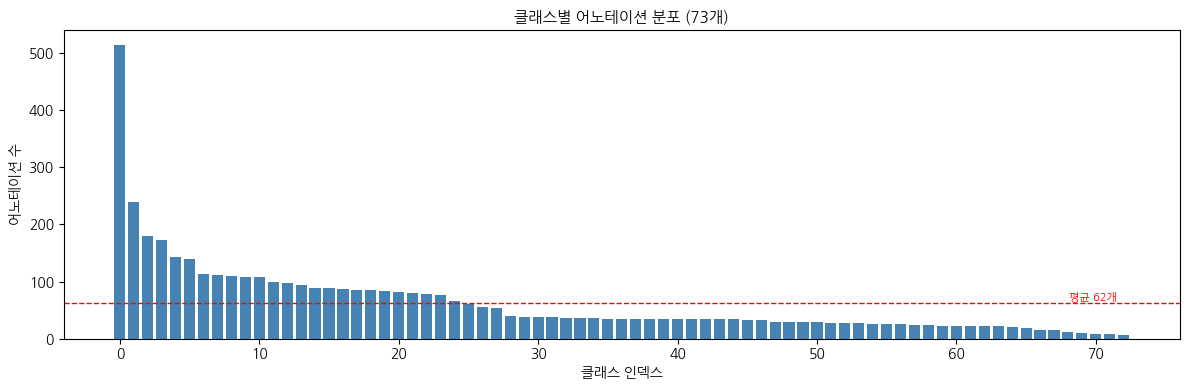

In [ ]:
# 클래스 분포 확인
id2name = {cat['id']: cat['name'] for cat in train_json['categories']}
cat_counter = Counter(annot['category_id'] for annot in train_json['annotations'])

df_class = pd.DataFrame([
    {'category_id': cid, 'name': id2name.get(cid, '?'), 'count': cnt}
    for cid, cnt in cat_counter.most_common()
])

print(f"클래스 수 : {len(df_class)}  |  전체 어노테이션 : {df_class['count'].sum():,}")
print(f"평균 : {df_class['count'].mean():.1f}  |  중앙값 : {df_class['count'].median():.1f}  |  최대/최소 비율 : {df_class['count'].max() / df_class['count'].min():.1f}x")
print(f"\n최다 : {df_class.iloc[0]['name']} ({df_class.iloc[0]['count']}개)")
print(f"최소 : {df_class.iloc[-1]['name']} ({df_class.iloc[-1]['count']}개)")

print("\n상위 5개:")
print(df_class.head(5)[['name', 'count']].to_string(index=False))
print("\n하위 5개:")
print(df_class.tail(5)[['name', 'count']].to_string(index=False))

# 전체 분포 시각화
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(df_class)), df_class['count'], color='steelblue', edgecolor='none')
mean_val = df_class['count'].mean()
ax.axhline(mean_val, color='red', linestyle='--', linewidth=1)
ax.text(len(df_class) * 0.98, mean_val + 5, f"평균 {mean_val:.0f}개", color='red', fontsize=8, ha='right')
ax.set_title('클래스별 어노테이션 분포 (73개)', fontsize=11)
ax.set_xlabel('클래스 인덱스')
ax.set_ylabel('어노테이션 수')
plt.tight_layout()
plt.show()

[Train] 해상도 분포:
  976 x 1280: 1489장
[Test] 해상도 분포:
  976 x 1280: 843장

annotation 없는 이미지: 0장
평균 알약 수: 3.04개 | 최대: 4개

  1개:   64장 (4.3%)
  2개:  302장 (20.3%)
  3개:  634장 (42.6%)
  4개:  489장 (32.8%)


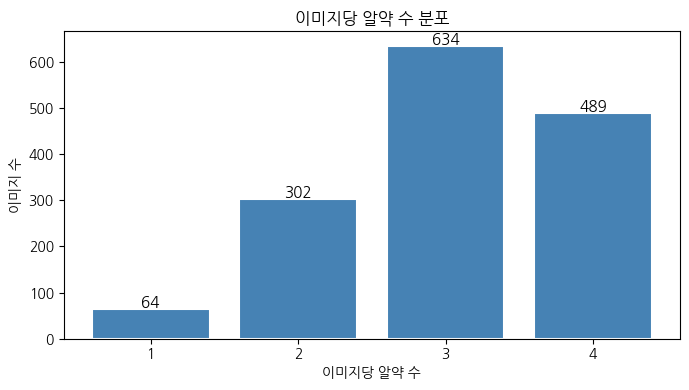

In [ ]:
# 해상도 및 알약 수 분포 확인
for label, data in [("Train", train_json), ("Test", test_json)]:
    resolutions = Counter((img['width'], img['height']) for img in data['images'])
    print(f"[{label}] 해상도 분포:")
    for (w, h), cnt in resolutions.most_common():
        print(f"  {w} x {h}: {cnt}장")

ann_per_image = Counter(ann['image_id'] for ann in train_json['annotations'])
no_ann = {img['id'] for img in train_json['images']} - set(ann_per_image.keys())
print(f"\nannotation 없는 이미지: {len(no_ann)}장")

counts = list(ann_per_image.values())
pill_dist = Counter(counts)
print(f"평균 알약 수: {np.mean(counts):.2f}개 | 최대: {np.max(counts)}개\n")
for k in sorted(pill_dist.keys()):
    print(f"  {k}개: {pill_dist[k]:4d}장 ({pill_dist[k]/len(train_json['images'])*100:.1f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
keys, vals = zip(*sorted(pill_dist.items()))
bars = ax.bar(keys, vals, color='steelblue', edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 5, str(v), ha='center', fontsize=11, fontweight='bold')
ax.set_xlabel('이미지당 알약 수')
ax.set_ylabel('이미지 수')
ax.set_title('이미지당 알약 수 분포')
ax.set_xticks(keys)
plt.tight_layout()
plt.show()

In [ ]:
# 비정상 BBox 탐지
img_id2info = {img['id']: img for img in train_json['images']}
invalid_bboxes = []

for ann in train_json['annotations']:
    img = img_id2info[ann['image_id']]
    x, y, w, h = ann['bbox']
    iw, ih = img['width'], img['height']

    reasons = []
    if x < 0 or y < 0:           reasons.append(f"음수 좌표 (x={x}, y={y})")
    if w <= 0 or h <= 0:          reasons.append(f"비정상 크기 (w={w}, h={h})")
    if x + w > iw:                reasons.append(f"x 범위 초과 (x+w={x+w} > {iw})")
    if y + h > ih:                reasons.append(f"y 범위 초과 (y+h={y+h} > {ih})")
    if reasons:
        invalid_bboxes.append({
            'ann_id'  : ann['id'],
            'image_id': ann['image_id'],
            'bbox'    : ann['bbox'],
            'reason'  : ' / '.join(reasons)
        })

print(f"비정상 BBox 수: {len(invalid_bboxes)}개")
for item in invalid_bboxes:
    print(f"  ann_id={item['ann_id']} / image_id={item['image_id']} / bbox={item['bbox']} / 사유={item['reason']}")

비정상 BBox 수: 2개
  ann_id=903 / image_id=239 / bbox=[6567, 625, 311, 315] / 사유=x 범위 초과 (x+w=6878 > 976)
  ann_id=1157 / image_id=310 / bbox=[653, 8889, 217, 217] / 사유=y 범위 초과 (y+h=9106 > 1280)


In [ ]:
# ── file_name ↔ 실제 파일 매칭 검증 ──────────────────────
actual_files = {entry.name for entry in os.scandir(TRAIN_IMG_DIR) if entry.is_file()}

missing = []
for img in train_json['images']:
    if img['file_name'] not in actual_files:
        missing.append(img['file_name'])

print(f"JSON 등록 이미지 수  : {len(train_json['images']):,}장")
print(f"실제 파일 수         : {len(actual_files):,}장")
print(f"매칭 실패 (누락 파일): {len(missing)}장")

if missing:
    print("\n누락 파일 목록:")
    for f in missing:
        print(f"  {f}")
else:
    print("모든 파일 정상 매칭")

JSON 등록 이미지 수  : 1,489장
실제 파일 수         : 1,489장
매칭 실패 (누락 파일): 0장
모든 파일 정상 매칭


## 5. 데이터 전처리 ##

### 5-1. 비정상 BBox 제거 ###

In [ ]:
# 비정상 BBox 제거
invalid_ann_ids = {item['ann_id'] for item in invalid_bboxes}
clean_annotations = [ann for ann in train_json['annotations'] if ann['id'] not in invalid_ann_ids]

print(f"제거 전 : {len(train_json['annotations']):,}개")
print(f"제거 수 : {len(invalid_ann_ids)}개")
print(f"제거 후 : {len(clean_annotations):,}개")

제거 전 : 4,526개
제거 수 : 2개
제거 후 : 4,524개


### 5-2. category_id 재맵핑

In [ ]:
# category_id 재매핑 (원본 id → 0~72 연속 정수)
sorted_cats = sorted(train_json['categories'], key=lambda c: c['id'])

old_id2new  = {cat['id']: new_id for new_id, cat in enumerate(sorted_cats)}
new_id2old  = {new_id: cat['id'] for new_id, cat in enumerate(sorted_cats)}
new_id2name = {new_id: cat['name'].strip() for new_id, cat in enumerate(sorted_cats)}

remapped_annotations = []
for ann in clean_annotations:
    new_ann = ann.copy()
    new_ann['category_id'] = old_id2new[ann['category_id']]
    remapped_annotations.append(new_ann)

remapped_categories = [
    {'id': new_id, 'name': new_id2name[new_id], 'supercategory': 'pill'}
    for new_id in range(len(sorted_cats))
]

new_cat_ids = sorted(set(ann['category_id'] for ann in remapped_annotations))
print(f"category_id 범위 : {min(new_cat_ids)} ~ {max(new_cat_ids)}")
print(f"고유 클래스 수   : {len(new_cat_ids)}개")
print(f"연속성           : {'연속' if new_cat_ids == list(range(len(new_cat_ids))) else '[경고] 불연속'}")
print(f"annotation 수    : {len(remapped_annotations):,}개")

category_id 범위 : 0 ~ 72
고유 클래스 수   : 73개
연속성           : 연속
annotation 수    : 4,524개


### 5-3. letterbox 리사이즈 (삭제) ###
976x1280 

원본 사이즈 사용

### 5-4. train/val 분리 ###

***Multi-label Stratified Split**

동작 방식

- 이미지 내 모든 클래스를 동시에 고려해 분할
- 각 클래스의 train/val 비율이 동시에 80:20에 가깝도록 최적화
- iterative-stratification 라이브러리 사용

In [ ]:
# Train/Val Multi-label Stratified Split
processed_annotations = remapped_annotations

# 이미지별 annotation 그룹화
img2anns = {}
for ann in processed_annotations:
    img2anns.setdefault(ann['image_id'], []).append(ann)

img_ids   = np.array(sorted(img2anns.keys()))
n_classes = len(remapped_categories)

# 이미지별 멀티핫 벡터 생성 (73차원)
y = np.zeros((len(img_ids), n_classes), dtype=int)
for i, img_id in enumerate(img_ids):
    for ann in img2anns[img_id]:
        y[i, ann['category_id']] = 1

# 클래스당 이미지 1장인 경우 강제 train 배정
class_counts     = y.sum(axis=0)
single_classes   = np.where(class_counts == 1)[0]
force_train_mask = np.any(y[:, single_classes] == 1, axis=1) if len(single_classes) > 0 else np.zeros(len(img_ids), dtype=bool)

remaining_idx = np.where(~force_train_mask)[0]
force_idx     = np.where(force_train_mask)[0]

# Multi-label stratified split
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(msss.split(remaining_idx, y[remaining_idx]))

train_ids = img_ids[remaining_idx[train_idx]].tolist() + img_ids[force_idx].tolist()
val_ids   = img_ids[remaining_idx[val_idx]].tolist()

# 검증
train_y = y[[i for i, img_id in enumerate(img_ids) if img_id in set(train_ids)]]
val_y   = y[[i for i, img_id in enumerate(img_ids) if img_id in set(val_ids)]]

print(f"Train : {len(train_ids)}장 | Val : {len(val_ids)}장")
print(f"Train 클래스 수 : {train_y.sum(axis=0).astype(bool).sum()}개")
print(f"Val   클래스 수 : {val_y.sum(axis=0).astype(bool).sum()}개")
print(f"강제 train 배정 : {len(force_idx)}장")

Train : 1182장 | Val : 307장
Train 클래스 수 : 73개
Val   클래스 수 : 73개
강제 train 배정 : 0장


In [ ]:
# [셀 11-1] 오버샘플링 (Train only, annotation < 62 클래스 대상) - 수정본 v2
print("수정본 v2 실행됨")
import copy
from collections import defaultdict, Counter

TARGET_COUNT = 62

# Train 이미지 id 세트
train_img_id_set = set(train_ids)

# Train annotation만 추출
train_anns = [ann for ann in remapped_annotations if ann["image_id"] in train_img_id_set]

# 클래스별 Train annotation 수 집계 (공유 카운터)
running_count = Counter(ann["category_id"] for ann in train_anns)

# 오버샘플링 대상 클래스
target_classes = {cid for cid, cnt in running_count.items() if cnt < TARGET_COUNT}
print(f"오버샘플링 대상 클래스 수: {len(target_classes)}개")

# 클래스 → 해당 클래스를 포함하는 Train 이미지 id 목록 (중복 제거)
cls_to_img_ids = defaultdict(list)
for ann in train_anns:
    if ann["category_id"] in target_classes:
        cls_to_img_ids[ann["category_id"]].append(ann["image_id"])
for cid in cls_to_img_ids:
    cls_to_img_ids[cid] = list(set(cls_to_img_ids[cid]))

# 이미지 id → 이미지 정보, 이미지 id → annotation 목록
img_id_to_info = {img["id"]: img for img in train_json["images"]}
img_id_to_anns = defaultdict(list)
for ann in remapped_annotations:
    img_id_to_anns[ann["image_id"]].append(ann)

# 이미지별 클래스 annotation 수 미리 계산
img_cid_count = defaultdict(lambda: defaultdict(int))
for ann in train_anns:
    img_cid_count[ann["image_id"]][ann["category_id"]] += 1

# 오버샘플링 실행
new_images = []
new_anns   = []
new_img_id = max(img["id"] for img in train_json["images"]) + 1
new_ann_id = max(ann["id"] for ann in remapped_annotations) + 1

for cid in target_classes:
    src_img_ids = cls_to_img_ids[cid]
    idx         = 0
    stall_count = 0

    while running_count[cid] < TARGET_COUNT:
        src_id    = src_img_ids[idx % len(src_img_ids)]
        add_count = img_cid_count[src_id][cid]

        if running_count[cid] + add_count <= TARGET_COUNT:
            new_img       = copy.deepcopy(img_id_to_info[src_id])
            new_img["id"] = new_img_id
            new_images.append(new_img)
            for ann in img_id_to_anns[src_id]:
                new_ann             = copy.deepcopy(ann)
                new_ann["id"]       = new_ann_id
                new_ann["image_id"] = new_img_id
                new_anns.append(new_ann)
                new_ann_id += 1
                # 모든 클래스 카운터 동시 업데이트
                running_count[ann["category_id"]] += 1
            new_img_id  += 1
            stall_count  = 0
        else:
            stall_count += 1

        if stall_count >= len(src_img_ids):
            break

        idx += 1

print(f"추가된 이미지 수: {len(new_images)}장")
print(f"추가된 annotation 수: {len(new_anns)}개")

# 오버샘플링 적용된 최종 annotation 리스트
oversampled_annotations = remapped_annotations + new_anns
new_img_id_set          = {img["id"] for img in new_images}

# 전후 비교 출력 (before는 원본 train 기준)
original_count = Counter(ann["category_id"] for ann in train_anns)
print(f"\n=== 오버샘플링 전후 비교 (대상 클래스) ===")
print(f"{'class_id':>10} {'class_name':<40} {'before':>8} {'after':>8}")
for cid in sorted(target_classes):
    name   = new_id2name.get(cid, "unknown")
    before = original_count[cid]
    after  = running_count[cid]
    print(f"{cid:>10} {name:<40} {before:>8} {after:>8}")

수정본 v2 실행됨
오버샘플링 대상 클래스 수: 51개
추가된 이미지 수: 1365장
추가된 annotation 수: 4247개

=== 오버샘플링 전후 비교 (대상 클래스) ===
  class_id class_name                                 before    after
         5 알드린정                                           43      106
         6 뉴로메드정(옥시라세탐)                                   22       73
         7 타이레놀정500mg                                     26       72
         8 에어탈정(아세클로페낙)                                   23      165
         9 삼남건조수산화알루미늄겔정                                  44       94
        10 타이레놀이알서방정(아세트아미노펜)(수출용)                        28       70
        11 삐콤씨에프정 618.6mg/병                               27       72
        12 조인스정 200mg                                     28      162
        13 쎄로켈정 100mg                                     28       65
        14 리렉스펜정 300mg/PTP                                28       69
        15 아빌리파이정 10mg                                    13       65
        16 자이프렉사정 2.5mg                                   

### 5-5. 전처리된 JSON 저장 ###

In [ ]:
# [셀 12] 전처리 JSON 저장 (v4)
processed_json = {
    'images'     : train_json['images'] + new_images,
    'annotations': oversampled_annotations,
    'categories' : remapped_categories,
    'train_ids'  : list(train_ids),
    'val_ids'    : list(val_ids),
    'mappings'   : {
        'old_id2new' : {str(k): v for k, v in old_id2new.items()},
        'new_id2old' : {str(k): v for k, v in new_id2old.items()},
        'new_id2name': {str(k): v for k, v in new_id2name.items()},
    }
}

with open(PROCESSED_JSON_PATH, 'w', encoding='utf-8') as f:
    json.dump(processed_json, f, ensure_ascii=False, indent=2)

with open(PROCESSED_JSON_PATH, 'r', encoding='utf-8') as f:
    verify = json.load(f)

print(f"images      : {len(verify['images']):,}장")
print(f"annotations : {len(verify['annotations']):,}개")
print(f"categories  : {len(verify['categories'])}개")
print(f"train_ids   : {len(verify['train_ids']):,}장")
print(f"val_ids     : {len(verify['val_ids']):,}장")
cat_ids = [ann['category_id'] for ann in verify['annotations']]
print(f"category_id : {min(cat_ids)} ~ {max(cat_ids)}")

images      : 2,854장
annotations : 8,771개
categories  : 73개
train_ids   : 1,182장
val_ids     : 307장
category_id : 0 ~ 72


### 5-6. 전처리 결과 검증 ###

In [ ]:
# [셀 13] 전처리 최종 검증 (v4)
train_id_set      = set(train_ids)
val_id_set        = set(val_ids)
all_images        = train_json['images'] + new_images

train_annotations = [ann for ann in oversampled_annotations if ann['image_id'] in train_id_set or ann['image_id'] in new_img_id_set]
val_annotations   = [ann for ann in oversampled_annotations if ann['image_id'] in val_id_set]

# 1. BBox 좌표 범위 검증
img_id2info = {img['id']: img for img in all_images}
bbox_errors = []
for ann in oversampled_annotations:
    img_info = img_id2info.get(ann['image_id'])
    if img_info is None:
        continue
    x, y, w, h = ann['bbox']
    iw = img_info['width']
    ih = img_info['height']
    reasons = []
    if x < 0 or y < 0:  reasons.append(f"음수 좌표 (x={x:.1f}, y={y:.1f})")
    if w <= 0 or h <= 0: reasons.append(f"비정상 크기 (w={w:.1f}, h={h:.1f})")
    if x + w > iw:       reasons.append(f"x 범위 초과 ({x+w:.1f} > {iw})")
    if y + h > ih:       reasons.append(f"y 범위 초과 ({y+h:.1f} > {ih})")
    if reasons:
        bbox_errors.append({'ann_id': ann['id'], 'reason': ' / '.join(reasons)})

print(f"비정상 BBox : {len(bbox_errors)}개" + (f"\n  {bbox_errors}" if bbox_errors else " (정상)"))

# 2. Train/Val 클래스 분포 비율 검증 (원본 기준)
original_annotations = [ann for ann in remapped_annotations]
total_cat_counts = Counter(ann['category_id'] for ann in original_annotations)
train_cat_counts = Counter(ann['category_id'] for ann in train_annotations)
val_cat_counts   = Counter(ann['category_id'] for ann in val_annotations)

print(f"\n{'new_id':<8} {'클래스명':<40} {'전체':>6} {'Train':>6} {'Val':>5} {'Val비율':>8}")
print("-" * 70)
ratio_errors = []
for cat_id in range(len(remapped_categories)):
    total     = total_cat_counts.get(cat_id, 0)
    train     = train_cat_counts.get(cat_id, 0)
    val       = val_cat_counts.get(cat_id, 0)
    val_ratio = val / total if total > 0 else 0
    flag      = " [경고]" if abs(val_ratio - 0.2) > 0.15 and total >= 5 else ""
    print(f"  {cat_id:<6} {new_id2name[cat_id]:<40} {total:>6} {train:>6} {val:>5} {val_ratio:>7.1%}{flag}")
    if flag:
        ratio_errors.append(cat_id)

print(f"\n비율 이상 클래스 : {len(ratio_errors)}개")
print(f"Train 클래스 수  : {len(train_cat_counts)}개")
print(f"Val   클래스 수  : {len(val_cat_counts)}개")
print(f"\nTrain annotation 수 (오버샘플링 포함) : {len(train_annotations):,}개")
print(f"Val   annotation 수                  : {len(val_annotations):,}개")

비정상 BBox : 0개 (정상)

new_id   클래스명                                         전체  Train   Val    Val비율
----------------------------------------------------------------------
  0      보령부스파정 5mg                                  180    353    36   20.0%
  1      뮤테란캡슐 100mg                                 172    319    32   18.6%
  2      일양하이트린정 2mg                                 240    585    48   20.0%
  3      기넥신에프정(은행엽엑스)(수출용)                          514    421   103   20.0%
  4      무코스타정(레바미피드)(비매품)                            98    374    20   20.4%
  5      알드린정                                         54    106    11   20.4%
  6      뉴로메드정(옥시라세탐)                                 27     73     5   18.5%
  7      타이레놀정500mg                                   33     72     7   21.2%
  8      에어탈정(아세클로페낙)                                 29    165     6   20.7%
  9      삼남건조수산화알루미늄겔정                                56     94    12   21.4%
  10     타이레놀이알서방정(아세트아미노펜)(수출용)                  

## 6. DataLoader 구성 ##

### 6-1. 이미지 포멧 변환 ###

COCO(기존 이미지 형식) [x, y, w, h] → YOLO [x_center, y_center, w, h]

심볼릭 링크(Symbolic Link)를 사용하여 실제 파일을 복사하지 않고, 원본 파일의 경로를 가리키는 포인터를 만들어 사용한다.

심볼릭 링크는 실제 파일 없이 원본을 참조하므로 용량 추가 없이 YOLO가 요구하는 디렉토리 구조를 만들 수 있습니다.

In [ ]:
# [셀 14] YOLO 포맷 변환 (v4)
YOLO_LABEL_TRAIN = os.path.join(YOLO_DATASET_DIR, "labels", "train")
YOLO_LABEL_VAL   = os.path.join(YOLO_DATASET_DIR, "labels", "val")
YOLO_IMG_TRAIN   = os.path.join(YOLO_DATASET_DIR, "images", "train")
YOLO_IMG_VAL     = os.path.join(YOLO_DATASET_DIR, "images", "val")
YOLO_YAML_PATH   = os.path.join(YOLO_DATASET_DIR, "data.yaml")

for d in [YOLO_LABEL_TRAIN, YOLO_LABEL_VAL, YOLO_IMG_TRAIN, YOLO_IMG_VAL]:
    os.makedirs(d, exist_ok=True)

def coco_to_yolo(bbox, img_w, img_h):
    x, y, w, h = bbox
    x_c = min(max((x + w / 2) / img_w, 0.0), 1.0)
    y_c = min(max((y + h / 2) / img_h, 0.0), 1.0)
    w_n = min(max(w / img_w, 0.0), 1.0)
    h_n = min(max(h / img_h, 0.0), 1.0)
    return x_c, y_c, w_n, h_n

# 오버샘플링 이미지: {new_img_id}_{file_name} 형태로 고유 파일명 부여
new_img_id2fname = {
    img["id"]: f"{img['id']}_{img['file_name']}"
    for img in new_images
}

# 전체 이미지 정보 (원본 + 오버샘플링)
all_images_list = train_json["images"] + new_images

# image_id → file_name 매핑 (고유 파일명 적용)
img_id2fname = {}
for img in train_json["images"]:
    img_id2fname[img["id"]] = img["file_name"]
for img in new_images:
    img_id2fname[img["id"]] = new_img_id2fname[img["id"]]

# image_id → annotation 목록
img_id2anns = {}
for ann in oversampled_annotations:
    img_id2anns.setdefault(ann["image_id"], []).append(ann)

# image_id → 이미지 정보
img_id2info = {img["id"]: img for img in all_images_list}

def write_yolo(img_ids, label_dir, img_dir, is_train=False):
    img_id_set = set(img_ids)
    # 오버샘플링 이미지 id는 train에만 포함
    if is_train:
        img_id_set = img_id_set | new_img_id_set
    count = 0
    for img_id in img_id_set:
        img_info  = img_id2info.get(img_id)
        if img_info is None:
            continue
        fname      = img_id2fname[img_id]
        stem       = os.path.splitext(fname)[0]
        label_path = os.path.join(label_dir, stem + ".txt")
        with open(label_path, "w") as f:
            for ann in img_id2anns.get(img_id, []):
                x_c, y_c, w_n, h_n = coco_to_yolo(
                    ann["bbox"], img_info["width"], img_info["height"]
                )
                f.write(f"{ann['category_id']} {x_c:.6f} {y_c:.6f} {w_n:.6f} {h_n:.6f}\n")
        shutil.copy2(
            os.path.join(TRAIN_IMG_DIR, img_info["file_name"]),
            os.path.join(img_dir, fname)
        )
        count += 1
    return count

n_train = write_yolo(train_ids, YOLO_LABEL_TRAIN, YOLO_IMG_TRAIN, is_train=True)
n_val   = write_yolo(val_ids,   YOLO_LABEL_VAL,   YOLO_IMG_VAL,   is_train=False)

yaml_content = f"""train: {YOLO_IMG_TRAIN}
val: {YOLO_IMG_VAL}

nc: {len(remapped_categories)}
names: {[new_id2name[i] for i in range(len(remapped_categories))]}
"""
with open(YOLO_YAML_PATH, "w", encoding="utf-8") as f:
    f.write(yaml_content)

n_ti = len(os.listdir(YOLO_IMG_TRAIN))
n_vi = len(os.listdir(YOLO_IMG_VAL))
n_tl = len(os.listdir(YOLO_LABEL_TRAIN))
n_vl = len(os.listdir(YOLO_LABEL_VAL))

print(f"Train 이미지: {n_ti:,} / 라벨: {n_tl:,}")
print(f"Val   이미지: {n_vi:,} / 라벨: {n_vl:,}")
if n_ti != n_tl: print("[경고] Train 이미지/라벨 수 불일치")
if n_vi != n_vl: print("[경고] Val 이미지/라벨 수 불일치")

sample = os.listdir(YOLO_LABEL_TRAIN)[0]
print(f"\n샘플 라벨 ({sample}):")
with open(os.path.join(YOLO_LABEL_TRAIN, sample)) as f:
    print(f.read())

Train 이미지: 2,547 / 라벨: 2,547
Val   이미지: 307 / 라벨: 307

샘플 라벨 (K-001900-016551-024850-027926_0_2_0_2_90_000_200.txt):
0 0.265369 0.245703 0.206967 0.099219
23 0.773566 0.215234 0.413934 0.313281



### 6-2. 모델 학습 코드

In [ ]:
# [셀 15] YOLOv8m 학습 (v4)
EXPERIMENT_NAME = "yolov8m_oral_drug_v4"

def on_train_epoch_end(trainer):
    epoch    = trainer.epoch + 1
    epochs   = trainer.epochs
    box_loss = trainer.loss_items[0].item() if trainer.loss_items is not None else 0
    cls_loss = trainer.loss_items[1].item() if trainer.loss_items is not None else 0
    dfl_loss = trainer.loss_items[2].item() if trainer.loss_items is not None else 0
    print(f"[Epoch {epoch:3d}/{epochs}]  box_loss: {box_loss:.4f}  cls_loss: {cls_loss:.4f}  dfl_loss: {dfl_loss:.4f}")

def on_val_end(validator):
    metrics = validator.metrics
    map50   = metrics.box.map50 if hasattr(metrics, 'box') else 0
    map5095 = metrics.box.map   if hasattr(metrics, 'box') else 0
    print(f"           └─ Val  mAP50: {map50:.4f}  mAP50-95: {map5095:.4f}")

def on_train_end(trainer):
    print(f"\n{'='*55}")
    print(f"학습 완료  |  저장 경로: {trainer.save_dir}")
    print(f"{'='*55}")

model = YOLO("yolov8m.pt")
model.add_callback("on_train_epoch_end", on_train_epoch_end)
model.add_callback("on_val_end",         on_val_end)
model.add_callback("on_train_end",       on_train_end)

results = model.train(
    data         = YOLO_YAML_PATH,
    imgsz        = 1280,
    rect         = True,
    epochs       = 50,
    batch        = 16,
    optimizer    = "AdamW",
    lr0          = 0.001,
    lrf          = 0.01,
    weight_decay = 0.0005,
    warmup_epochs= 3,
    mosaic       = 1.0,
    mixup        = 0.1,
    hsv_h        = 0.0,
    hsv_s        = 0.0,
    hsv_v        = 0.0,
    degrees      = 0.0,
    fliplr       = 0.0,
    flipud       = 0.0,
    patience     = 20,
    save         = True,
    project      = YOLO_RUNS_DIR,
    name         = EXPERIMENT_NAME,
    exist_ok     = True,
    device       = 0,
    workers      = 8,
    verbose      = False,
)

Ultralytics 8.4.26 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/data/초급_프로젝트/dataset/yolo_dataset_v4/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m_oral_drug_v4, nbs=64, nms=False, opset=None, optimize=False, optimizer

In [ ]:
# [확인] v4 클래스별 성능 분석
from ultralytics import YOLO
import pandas as pd

BEST_PT_PATH   = f"{BASE_DIR}/yolo_runs_v4/yolov8m_oral_drug_v4/weights/best.pt"
DATA_YAML_PATH = f"{BASE_DIR}/yolo_dataset_v4/data.yaml"

model = YOLO(BEST_PT_PATH)
val_results = model.val(
    data=DATA_YAML_PATH,
    imgsz=1280,
    batch=8,
    conf=0.25,
    iou=0.5,
    max_det=4,
    rect=True,
    device=0,
    verbose=False
)

# 클래스별 지표 추출
class_indices = val_results.box.ap_class_index.tolist()
precisions    = val_results.box.p.tolist()
recalls       = val_results.box.r.tolist()
ap50s         = val_results.box.ap50.tolist()

class_names = [val_results.names[i] for i in class_indices]

df = pd.DataFrame({
    "class_id"  : class_indices,
    "class_name": class_names,
    "Precision" : [round(p, 4) for p in precisions],
    "Recall"    : [round(r, 4) for r in recalls],
    "AP50"      : [round(a, 4) for a in ap50s],
})

print("=== 전체 클래스 성능 ===")
print(df.to_string(index=False))

print("\n=== AP50 하위 10개 클래스 (취약 클래스) ===")
print(df.nsmallest(10, "AP50").to_string(index=False))

print(f"\n전체 mAP50: {val_results.box.map50:.4f}")
print(f"AP50 == 0인 클래스 수: {(df['AP50'] == 0).sum()}개")

Ultralytics 8.4.26 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,882,027 parameters, 0 gradients, 78.9 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 392.8±32.5 MB/s, size: 1830.6 KB)
val: Scanning /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo_dataset_v4/labels/val.cache... 307 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 307/307 47.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 1.3it/s 30.1s0.7ss
                   all        307        917      0.786      0.985      0.869      0.865
Speed: 7.4ms preprocess, 80.8ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/val
=== 전체 클래스 성능 ===
 class_id               class_name  Precision  Recall   AP50
        0               보령부스파정 5mg     0.8182  1.0000 0.9149
        1              뮤테란캡슐 100mg     0.6531  1.0000 0.7300
        2              일양하이트린정

In [ ]:
# [확인] v4 전체 클래스별 annotation 수
import json
from collections import Counter
import pandas as pd

with open(f"{BASE_DIR}/processed_train_v4.json", "r") as f:
    processed = json.load(f)

new_id2name = {cat["id"]: cat["name"] for cat in processed["categories"]}
counter = Counter(ann["category_id"] for ann in processed["annotations"])
df_cls = pd.DataFrame([
    {
        "class_id"  : cid,
        "class_name": new_id2name.get(cid, "unknown"),
        "ann_count" : counter.get(cid, 0)
    }
    for cid in range(73)
]).sort_values("ann_count")

print(df_cls.to_string(index=False))
print(f"\n전체 annotation 수: {df_cls['ann_count'].sum()}")
print(f"클래스당 최소: {df_cls['ann_count'].min()}, 최대: {df_cls['ann_count'].max()}, 평균: {df_cls['ann_count'].mean():.1f}")

 class_id               class_name  ann_count
       65              브린텔릭스정 20mg         63
       16             자이프렉사정 2.5mg         64
       52              졸로푸트정 100mg         64
       57               렉사프로정 15mg         64
       42               쿠에타핀정 25mg         64
       27   종근당글리아티린연질캡슐(콜린알포세레이트)         66
       66           글리틴정(콜린알포세레이트)         66
       60          아질렉트정(라사길린메실산염)         67
       26              리리카캡슐 150mg         67
       71               카발린캡슐 25mg         67
       62                글리아타민연질캡슐         68
       15              아빌리파이정 10mg         68
       72                케이캡정 50mg         68
       41             메가파워정 90mg/병         69
       64              에스원엠프정 20mg         69
       40            맥시부펜이알정 300mg         71
       25           란스톤엘에프디티정 30mg         71
       43            비타비백정 100mg/병         71
       70           로수바미브정 10/20mg         71
       13               쎄로켈정 100mg         72
       37               라비에트정 20mg

In [ ]:
# [셀 16] 세션 복원 셀 (v4)
import os, json
import unicodedata
import numpy as np
from collections import Counter

BASE_DIR            = unicodedata.normalize('NFC', "/content/drive/MyDrive/data/초급_프로젝트/dataset/")
PROCESSED_JSON_PATH = os.path.join(BASE_DIR, "processed_train_v4.json")
TEST_IMG_DIR        = os.path.join(BASE_DIR, "test_images")
YOLO_DATASET_DIR    = os.path.join(BASE_DIR, "yolo_dataset_v4")
YOLO_RUNS_DIR       = os.path.join(BASE_DIR, "yolo_runs_v4")
SUBMISSION_PATH     = os.path.join(BASE_DIR, "submission_v4.csv")
YOLO_YAML_PATH      = os.path.join(YOLO_DATASET_DIR, "data.yaml")
MODEL_PATH          = os.path.join(YOLO_RUNS_DIR, "yolov8m_oral_drug_v4", "weights", "best.pt")

with open(PROCESSED_JSON_PATH, 'r', encoding='utf-8') as f:
    processed_json = json.load(f)

train_ids           = processed_json['train_ids']
val_ids             = processed_json['val_ids']
remapped_categories = processed_json['categories']

old_id2new  = {int(k): v for k, v in processed_json['mappings']['old_id2new'].items()}
new_id2old  = {int(k): v for k, v in processed_json['mappings']['new_id2old'].items()}
new_id2name = {int(k): v for k, v in processed_json['mappings']['new_id2name'].items()}

print(f"processed_json 로드 완료")
print(f"train_ids : {len(train_ids)}장 | val_ids : {len(val_ids)}장")
print(f"categories : {len(remapped_categories)}개")
print(f"MODEL_PATH : {'OK' if os.path.exists(MODEL_PATH) else '없음'} ({MODEL_PATH})")

processed_json 로드 완료
train_ids : 1182장 | val_ids : 307장
categories : 73개
MODEL_PATH : OK (/content/drive/MyDrive/data/초급_프로젝트/dataset/yolo_runs_v4/yolov8m_oral_drug_v4/weights/best.pt)


In [ ]:
# [셀 17] Inference + submission.csv 생성 (v4)
from ultralytics import YOLO
import pandas as pd

CONF_THRESHOLD = 0.25
IOU_THRESHOLD  = 0.5
MAX_DETS       = 4

model = YOLO(MODEL_PATH)

test_files = sorted([f for f in os.listdir(TEST_IMG_DIR) if f.endswith('.png')])

rows = []
annotation_id = 1

for f in test_files:
    img_path = os.path.join(TEST_IMG_DIR, f)
    image_id = int(os.path.splitext(f)[0])

    results = model.predict(
        source  = img_path,
        imgsz   = 1280,
        conf    = CONF_THRESHOLD,
        iou     = IOU_THRESHOLD,
        max_det = MAX_DETS,
        verbose = False,
    )

    boxes = results[0].boxes
    if boxes is None or len(boxes) == 0:
        continue

    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf     = float(box.conf[0])
        class_id = int(box.cls[0])
        orig_cat = new_id2old[class_id] + 1  # +1 보정

        rows.append({
            'annotation_id': annotation_id,
            'image_id'     : image_id,
            'category_id'  : orig_cat,
            'bbox_x'       : x1,
            'bbox_y'       : y1,
            'bbox_w'       : x2 - x1,
            'bbox_h'       : y2 - y1,
            'score'        : conf,
        })
        annotation_id += 1

df_submission = pd.DataFrame(rows)
df_submission.to_csv(SUBMISSION_PATH, index=False)

print(f"총 탐지 수       : {len(df_submission):,}개")
print(f"탐지 이미지 수   : {df_submission['image_id'].nunique():,}장 / {len(test_files)}장")
print(f"이미지당 평균    : {len(df_submission)/df_submission['image_id'].nunique():.2f}개")
print(f"등장 클래스 수   : {df_submission['category_id'].nunique()}개")
print(f"저장 경로        : {SUBMISSION_PATH}")

총 탐지 수       : 3,195개
탐지 이미지 수   : 843장 / 843장
이미지당 평균    : 3.79개
등장 클래스 수   : 73개
저장 경로        : /content/drive/MyDrive/data/초급_프로젝트/dataset/submission_v4.csv
